# Reprodução do Artigo: Detecção de Câncer de Pele com IA Explicável

**Referência:** *Explainable AI-Based Skin Cancer Detection Using CNN, Particle Swarm Optimization and Machine Learning*  
J. Imaging 2024, 10, 332

## Objetivo

Este notebook reproduz a metodologia proposta no artigo, que combina:
- **Experimento 1:** Transfer Learning com Xception
- **Experimento 2:** Extração de features + classificadores ML tradicionais (SVM, KNN, etc.)
- **Experimento 3:** Seleção de features via PSO (Particle Swarm Optimization) + Subspace KNN
- **XAI:** Técnicas de IA Explicável (Grad-CAM, LIME, Occlusion Sensitivity)

## Dataset
- **Treino:** 1440 imagens benignas + 1197 imagens malignas
- **Teste:** 360 imagens benignas + 300 imagens malignas
- **Após augmentação:** 5760 benignas + 4788 malignas no treino
- **Tamanho das imagens:** 224×224 pixels, RGB

## Instalação de Dependências

Instalação das bibliotecas necessárias que podem não estar presentes no ambiente.

In [1]:
# Instalar dependências adicionais necessárias para este notebook
!pip install pyswarms lime tf-keras-vis --quiet

## Importação de Bibliotecas

In [2]:
# ── Bibliotecas padrão ──────────────────────────────────────────────────────
import os
import glob
import warnings
import random
warnings.filterwarnings('ignore')

# ── Manipulação de dados ────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualização ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ── Processamento de imagens ────────────────────────────────────────────────
from PIL import Image, ImageFilter

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import img_to_array

# ── Scikit-learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)

# ── PSO (Particle Swarm Optimization) ──────────────────────────────────────
from pyswarms.discrete import BinaryPSO

# ── LIME (Local Interpretable Model-Agnostic Explanations) ─────────────────
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ── tf-keras-vis (disponível, mas Grad-CAM implementado manualmente por
#    compatibilidade com Keras 3 – ver Seção 6) ──────────────────────────────
# from tf_keras_vis.gradcam_plus_plus import GradcamPlusPlus
# from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
# from tf_keras_vis.utils.scores import CategoricalScore

# ── Configurações gerais ────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow versão: {tf.__version__}')
print(f'Keras versão: {keras.__version__}')
print(f'GPUs disponíveis: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1776694109.652930 2897362 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776694109.708274 2897362 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776694111.095172 2897362 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow versão: 2.21.0
Keras versão: 3.12.1
GPUs disponíveis: []


E0000 00:00:1776694111.647412 2897362 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Carregamento e Exploração dos Dados

Carregamos os caminhos das imagens e criamos DataFrames para facilitar a manipulação e visualização da distribuição das classes.

In [3]:
# ── Definição dos caminhos base ─────────────────────────────────────────────
DATA_DIR   = '/home/lmelo/others/Skin_Cancer_TransferLearning_XAI/data/'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
IMG_SIZE   = (224, 224)   # tamanho padrão exigido pelo Xception
BATCH_SIZE = 32

# ── Coleta de caminhos via glob ─────────────────────────────────────────────
def collect_paths(base_dir):
    """Retorna DataFrame com colunas 'path' e 'label' para todas as imagens."""
    records = []
    for label in ['benign', 'malignant']:
        pattern = os.path.join(base_dir, label, '*.jpg')
        paths = glob.glob(pattern)
        for p in paths:
            records.append({'path': p, 'label': label})
    return pd.DataFrame(records)

df_train = collect_paths(TRAIN_DIR)
df_test  = collect_paths(TEST_DIR)

print('=== Conjunto de Treino ===')
print(df_train['label'].value_counts())
print(f'Total: {len(df_train)} imagens\n')

print('=== Conjunto de Teste ===')
print(df_test['label'].value_counts())
print(f'Total: {len(df_test)} imagens')

=== Conjunto de Treino ===
label
benign       1440
malignant    1197
Name: count, dtype: int64
Total: 2637 imagens

=== Conjunto de Teste ===
label
benign       360
malignant    300
Name: count, dtype: int64
Total: 660 imagens


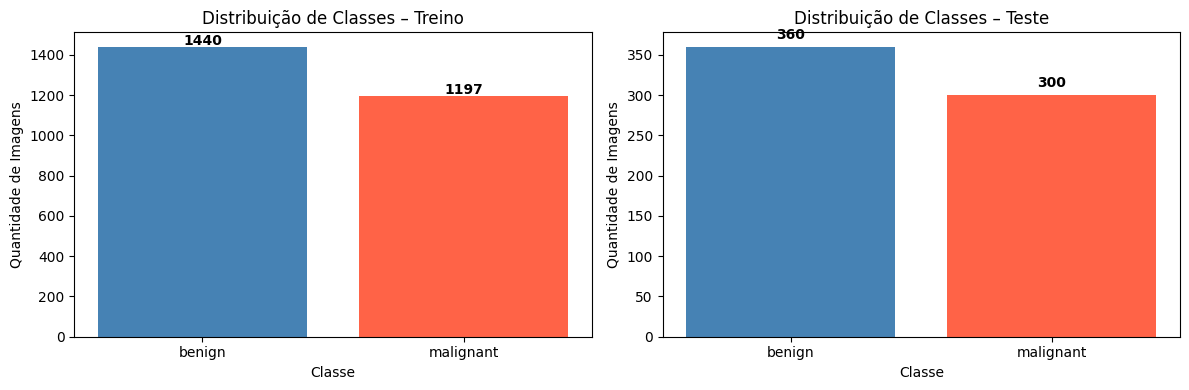

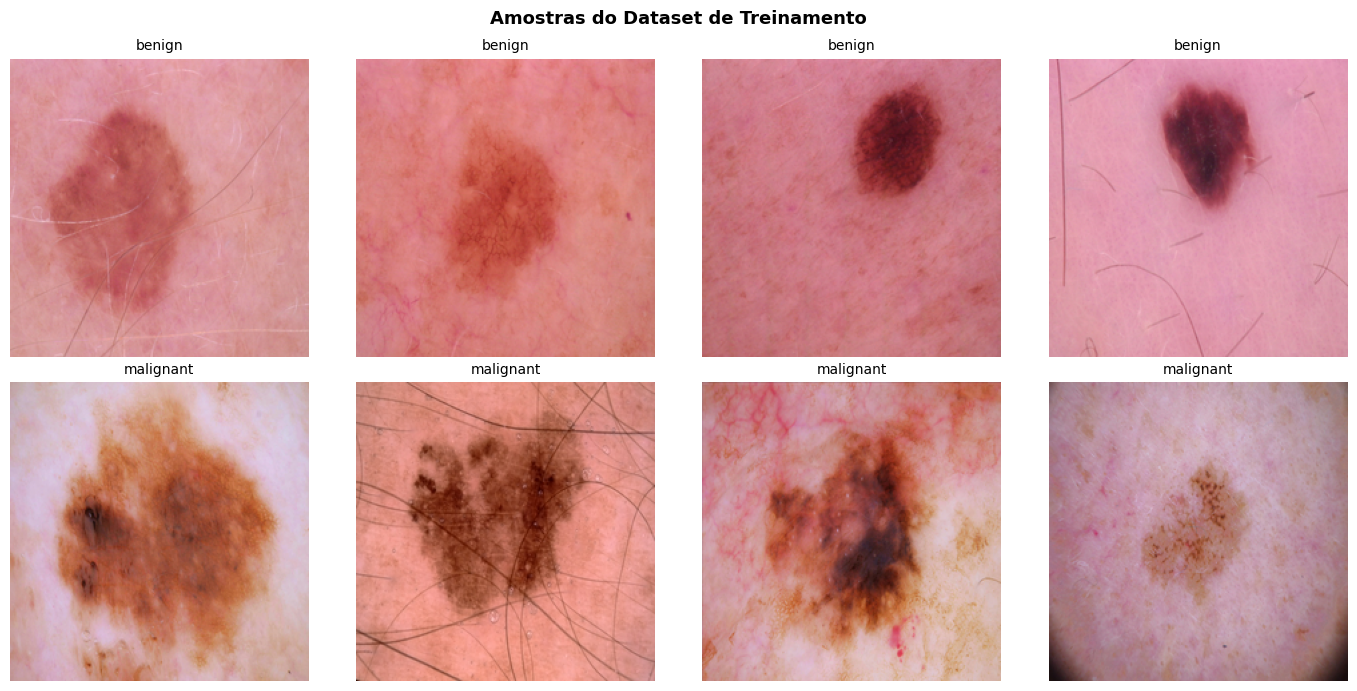

In [4]:
# ── Visualização da distribuição das classes ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, titulo) in zip(axes, [(df_train, 'Treino'), (df_test, 'Teste')]):
    contagens = df['label'].value_counts()
    ax.bar(contagens.index, contagens.values, color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição de Classes – {titulo}')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade de Imagens')
    for i, v in enumerate(contagens.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Exibir amostras do dataset ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, label in enumerate(['benign', 'malignant']):
    amostras = df_train[df_train['label'] == label].sample(4, random_state=SEED)
    for j, (_, row) in enumerate(amostras.iterrows()):
        img = Image.open(row['path']).resize(IMG_SIZE)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f'{label}', fontsize=10)
        axes[i, j].axis('off')

plt.suptitle('Amostras do Dataset de Treinamento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Pré-processamento e Augmentação

Conforme a Seção 3.1.3 do artigo, a augmentação é aplicada **apenas** aos dados de treino e inclui:
1. **Rotação aleatória:** de -180° a +180°
2. **Gaussian blur:** sigma=2
3. **Sharpening:** amount=2, radius=1, threshold=0

As imagens originais são mantidas, resultando em um fator de multiplicação de 4×:  
1440 × 4 = **5760 benignas** e 1197 × 4 = **4788 malignas**.

In [5]:
# ── Funções de carregamento e normalização ──────────────────────────────────
def load_image(path, size=IMG_SIZE):
    """Carrega imagem, redimensiona para 224×224 e normaliza para [0, 1]."""
    img = Image.open(path).convert('RGB').resize(size)
    return np.array(img, dtype=np.float32) / 255.0

# ── Funções de augmentação conforme o artigo ────────────────────────────────
def augment_rotation(img_array):
    """Rotação aleatória entre -180 e +180 graus."""
    angle = np.random.uniform(-180, 180)
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    rotated = pil_img.rotate(angle, resample=Image.BILINEAR)
    return np.array(rotated, dtype=np.float32) / 255.0

def augment_gaussian_blur(img_array, sigma=2):
    """Gaussian blur com sigma=2, conforme especificado no artigo."""
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    blurred = pil_img.filter(ImageFilter.GaussianBlur(radius=sigma))
    return np.array(blurred, dtype=np.float32) / 255.0

def augment_sharpen(img_array, amount=2, radius=1):
    """Sharpening com amount=2, radius=1, threshold=0, conforme artigo."""
    pil_img = Image.fromarray((img_array * 255).astype(np.uint8))
    sharpened = pil_img.filter(ImageFilter.UnsharpMask(radius=radius, percent=int(amount * 100), threshold=0))
    return np.array(sharpened, dtype=np.float32) / 255.0

print('Funções de augmentação definidas com sucesso.')

Funções de augmentação definidas com sucesso.


In [6]:
# ── Criação do dataset aumentado ────────────────────────────────────────────
# Para cada imagem original, geramos 3 versões aumentadas + original = 4 versões
# Isso resulta em 5760 benignas e 4788 malignas conforme o artigo.

def build_augmented_dataset(df):
    """Constrói arrays X e y com imagens originais + 3 augmentações."""
    X_list, y_list = [], []
    label_map = {'benign': 0, 'malignant': 1}

    print(f'Processando {len(df)} imagens originais...')
    for idx, row in df.iterrows():
        img = load_image(row['path'])
        lbl = label_map[row['label']]

        # Imagem original
        X_list.append(img)
        y_list.append(lbl)

        # Augmentação 1: Rotação
        X_list.append(augment_rotation(img))
        y_list.append(lbl)

        # Augmentação 2: Gaussian blur
        X_list.append(augment_gaussian_blur(img))
        y_list.append(lbl)

        # Augmentação 3: Sharpening
        X_list.append(augment_sharpen(img))
        y_list.append(lbl)

        if (idx + 1) % 200 == 0:
            print(f'  {idx + 1}/{len(df)} imagens processadas...')

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    print(f'Dataset aumentado: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

# ── Dataset de TESTE (sem augmentação) ──────────────────────────────────────
def build_test_dataset(df):
    """Constrói arrays X e y apenas com as imagens originais (sem augmentação)."""
    label_map = {'benign': 0, 'malignant': 1}
    X = np.array([load_image(p) for p in df['path']], dtype=np.float32)
    y = np.array([label_map[l] for l in df['label']], dtype=np.int32)
    print(f'Dataset de teste: {X.shape[0]} imagens ({np.sum(y==0)} benignas, {np.sum(y==1)} malignas)')
    return X, y

# Carrega dataset de teste
print('Carregando imagens de teste...')
X_test, y_test = build_test_dataset(df_test)

# Carrega dataset de treino AUMENTADO
print('\nCriando dataset de treino com augmentação...')
print('(Este processo pode levar alguns minutos)')
X_train_aug, y_train_aug = build_augmented_dataset(df_train)

Carregando imagens de teste...
Dataset de teste: 660 imagens (360 benignas, 300 malignas)

Criando dataset de treino com augmentação...
(Este processo pode levar alguns minutos)
Processando 2637 imagens originais...
  200/2637 imagens processadas...
  400/2637 imagens processadas...
  600/2637 imagens processadas...
  800/2637 imagens processadas...
  1000/2637 imagens processadas...
  1200/2637 imagens processadas...
  1400/2637 imagens processadas...
  1600/2637 imagens processadas...
  1800/2637 imagens processadas...
  2000/2637 imagens processadas...
  2200/2637 imagens processadas...
  2400/2637 imagens processadas...
  2600/2637 imagens processadas...
Dataset aumentado: 10548 imagens (5760 benignas, 4788 malignas)


In [7]:
# ── Divisão treino/validação: 70% treino, 30% validação ────────────────────
# Conforme o artigo (Section 3): divisão 70:30 do conjunto de treino
X_train, X_val, y_train, y_val = train_test_split(
    X_train_aug, y_train_aug,
    test_size=0.30,
    random_state=SEED,
    stratify=y_train_aug
)

print(f'Treino:    {X_train.shape[0]} amostras')
print(f'Validação: {X_val.shape[0]} amostras')
print(f'Teste:     {X_test.shape[0]} amostras')

# ── Conversão para one-hot encoding (necessário para softmax) ────────────────
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   num_classes=2)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  num_classes=2)

# ── Criar tf.data.Dataset para treinamento eficiente ────────────────────────
ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train_oh))\
    .shuffle(buffer_size=2000, seed=SEED)\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

ds_val = tf.data.Dataset.from_tensor_slices((X_val, y_val_oh))\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

ds_test = tf.data.Dataset.from_tensor_slices((X_test, y_test_oh))\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

print('\nDatasets TensorFlow criados com sucesso.')

Treino:    7383 amostras
Validação: 3165 amostras
Teste:     660 amostras


W0000 00:00:1776694173.829541 2897362 cpu_allocator_impl.cc:82] Allocation of 4445392896 exceeds 10% of free system memory.



Datasets TensorFlow criados com sucesso.


W0000 00:00:1776694177.819987 2897362 cpu_allocator_impl.cc:82] Allocation of 1905684480 exceeds 10% of free system memory.


## 3. Experimento 1: Xception com Transfer Learning

Conforme o artigo (Seção 3, Experimento 1), utilizamos o Xception pré-treinado no ImageNet com **todas as camadas congeladas** (100% frozen), que foi identificado como configuração ótima no estudo de ablação.

**Arquitetura adicionada ao topo:**
- Global Average Pooling
- Dense(512, ReLU)
- Dense(256, ReLU)
- Dense(2, Softmax)

**Resultados esperados:**
- Acurácia de validação: ~94.15%
- Acurácia de teste: ~89.24%

In [8]:
# ── Construção do modelo Xception com Transfer Learning ─────────────────────

# Base: Xception pré-treinado no ImageNet, sem a camada de classificação final
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar TODAS as camadas da base (100% frozen – configuração ótima do artigo)
base_model.trainable = False

# ── Camadas adicionadas ao topo ──────────────────────────────────────────────
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)   # training=False mantém BatchNorm em modo inferência
x       = layers.GlobalAveragePooling2D()(x)   # reduz para 2048 features no Xception
x       = layers.Dense(512, activation='relu')(x)
x       = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(2,   activation='softmax')(x)

model_exp1 = Model(inputs, outputs, name='Xception_TransferLearning')

# ── Compilação ───────────────────────────────────────────────────────────────
model_exp1.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo das camadas treináveis
trainable     = sum(tf.size(w).numpy() for w in model_exp1.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_exp1.non_trainable_weights)
print(f'Parâmetros treináveis:     {trainable:,}')
print(f'Parâmetros não treináveis: {non_trainable:,}')
model_exp1.summary()

Parâmetros treináveis:     1,180,930
Parâmetros não treináveis: 20,861,480


Model: "Xception_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,042,410 (84.09 MB)

 Trainable params: 1,180,930 (4.50 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [9]:
# ── Treinamento do Experimento 1 ─────────────────────────────────────────────
# O artigo treina por 5 épocas – o modelo atinge aprendizado ótimo nesse ponto.

EPOCHS = 5

history_exp1 = model_exp1.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_val,
    verbose=1
)

print('\nTreinamento concluído!')

Epoch 1/5


W0000 00:00:1776694180.180686 2897362 cpu_allocator_impl.cc:82] Allocation of 4445392896 exceeds 10% of free system memory.


231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7109 - loss: 0.5631

W0000 00:00:1776694629.005673 2897362 cpu_allocator_impl.cc:82] Allocation of 1905684480 exceeds 10% of free system memory.


231/231 ━━━━━━━━━━━━━━━━━━━━ 633s 3s/step - accuracy: 0.7777 - loss: 0.4538 - val_accuracy: 0.8139 - val_loss: 0.3986
Epoch 2/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 614s 3s/step - accuracy: 0.8505 - loss: 0.3335 - val_accuracy: 0.8240 - val_loss: 0.3707
Epoch 3/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.8644 - loss: 0.2940 - val_accuracy: 0.8509 - val_loss: 0.3288
Epoch 4/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 623s 3s/step - accuracy: 0.8769 - loss: 0.2675 - val_accuracy: 0.8566 - val_loss: 0.3164
Epoch 5/5
231/231 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/step - accuracy: 0.8988 - loss: 0.2252 - val_accuracy: 0.8689 - val_loss: 0.3173

Treinamento concluído!


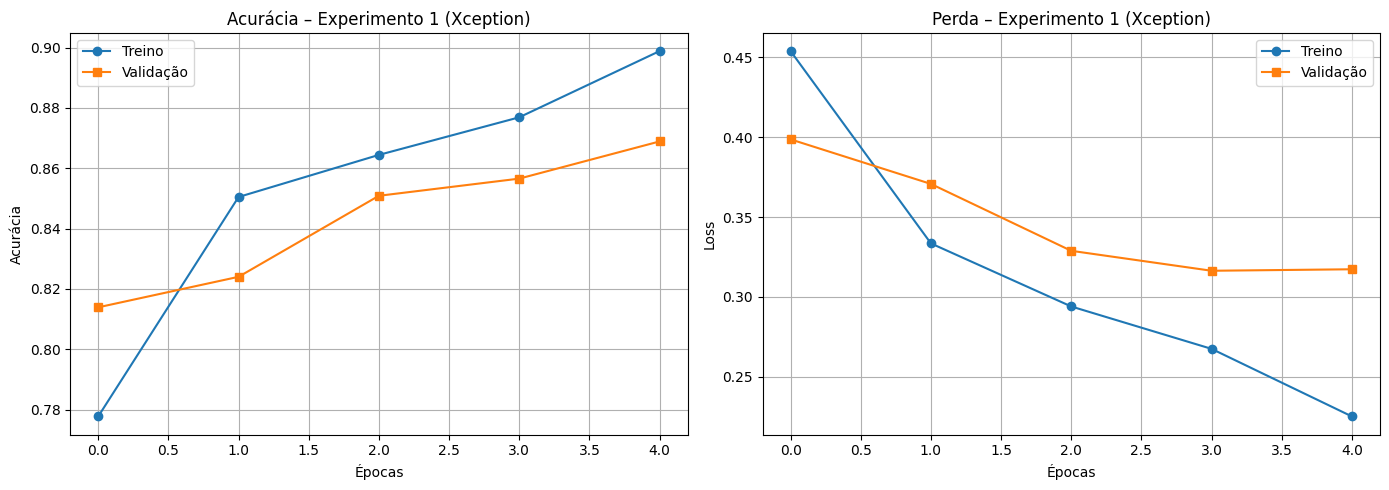

In [10]:
# ── Curvas de aprendizado ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Acurácia
axes[0].plot(history_exp1.history['accuracy'],     label='Treino',    marker='o')
axes[0].plot(history_exp1.history['val_accuracy'], label='Validação', marker='s')
axes[0].set_title('Acurácia – Experimento 1 (Xception)')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(True)

# Perda
axes[1].plot(history_exp1.history['loss'],     label='Treino',    marker='o')
axes[1].plot(history_exp1.history['val_loss'], label='Validação', marker='s')
axes[1].set_title('Perda – Experimento 1 (Xception)')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


=== Métricas – Experimento 1 – Xception TL ===
  Acurácia:         0.8091 (80.91%)
  Sensibilidade:    0.8433 (84.33%)
  Especificidade:   0.7806 (78.06%)
  Precisão:         0.7620 (76.20%)
  F1-Score:         0.8006 (80.06%)


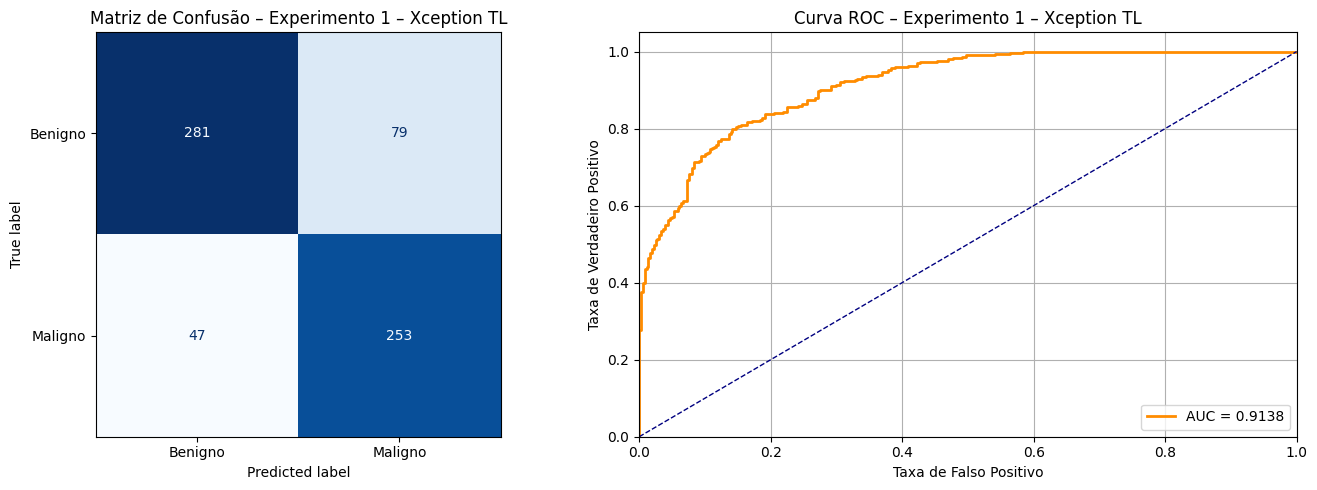

In [11]:
# ── Função auxiliar para calcular métricas detalhadas ───────────────────────
def compute_metrics(y_true, y_pred, y_prob, label='Experimento'):
    """
    Calcula e exibe: Acurácia, Sensibilidade (Recall maligno),
    Especificidade (Recall benigno), Precisão, F1-Score.
    """
    acc  = accuracy_score(y_true, y_pred)
    cm   = confusion_matrix(y_true, y_pred)
    # cm[0,0]=TN(benigno correto), cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP(maligno correto)
    TN, FP, FN, TP = cm.ravel()
    sensibilidade  = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # recall maligno
    especificidade = TN / (TN + FP) if (TN + FP) > 0 else 0.0  # recall benigno
    precisao       = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1             = 2 * precisao * sensibilidade / (precisao + sensibilidade) if (precisao + sensibilidade) > 0 else 0.0

    print(f'\n=== Métricas – {label} ===')
    print(f'  Acurácia:         {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Sensibilidade:    {sensibilidade:.4f} ({sensibilidade*100:.2f}%)')
    print(f'  Especificidade:   {especificidade:.4f} ({especificidade*100:.2f}%)')
    print(f'  Precisão:         {precisao:.4f} ({precisao*100:.2f}%)')
    print(f'  F1-Score:         {f1:.4f} ({f1*100:.2f}%)')

    # Matriz de confusão
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'Matriz de Confusão – {label}')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Taxa de Falso Positivo')
    axes[1].set_ylabel('Taxa de Verdadeiro Positivo')
    axes[1].set_title(f'Curva ROC – {label}')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'label': label,
        'acuracia': acc,
        'sensibilidade': sensibilidade,
        'especificidade': especificidade,
        'precisao': precisao,
        'f1': f1,
        'auc': roc_auc
    }

# ── Avaliação no conjunto de teste ──────────────────────────────────────────
y_prob_exp1 = model_exp1.predict(X_test, verbose=0)
y_pred_exp1 = np.argmax(y_prob_exp1, axis=1)

resultados = {}  # dicionário para consolidar resultados dos 3 experimentos
resultados['Exp1_Xception'] = compute_metrics(
    y_test, y_pred_exp1, y_prob_exp1, label='Experimento 1 – Xception TL'
)

## 4. Experimento 2: Extração de Features + Classificadores ML

Utilizamos o Xception como extrator de features (saída após o Global Average Pooling = **2048 features** no bloco de extração antes das camadas densas adicionadas). Em seguida, treinamos múltiplos classificadores de ML:

| Grupo | Classificador |
|-------|---------------|
| SVM | Linear, Medium Gaussian, Coarse Gaussian, Fine Gaussian |
| KNN | Fine, Medium, Coarse, Cosine, Weighted |
| Ensemble | Boosted Trees, Bagged Trees, Subspace Discriminant |

**Resultado chave do artigo:** Medium Gaussian SVM → 89.5% de acurácia no teste.

In [12]:
# ── Construção do modelo extrator de features ────────────────────────────────
# Usamos a saída do GlobalAveragePooling da base Xception (2048-dim)
# IMPORTANTE: NÃO aplicar augmentação para extração de features

feature_extractor = Model(
    inputs=model_exp1.input,
    outputs=model_exp1.layers[2].output,  # saída do GlobalAveragePooling
    name='Xception_FeatureExtractor'
)

print(f'Dimensão das features extraídas: {feature_extractor.output_shape}')

# ── Carregamento das imagens ORIGINAIS de treino (sem augmentação) ──────────
print('Carregando imagens originais de treino para extração de features...')
X_train_orig = np.array([load_image(p) for p in df_train['path']], dtype=np.float32)
y_train_orig = np.array([0 if l == 'benign' else 1 for l in df_train['label']], dtype=np.int32)

# ── Extração de features ─────────────────────────────────────────────────────
print('Extraindo features do conjunto de treino...')
feat_train = feature_extractor.predict(X_train_orig, batch_size=32, verbose=1)

print('Extraindo features do conjunto de teste...')
feat_test = feature_extractor.predict(X_test, batch_size=32, verbose=1)

print(f'\nShape features treino: {feat_train.shape}')
print(f'Shape features teste:  {feat_test.shape}')

# ── Normalização das features (StandardScaler) ───────────────────────────────
scaler = StandardScaler()
feat_train_scaled = scaler.fit_transform(feat_train)
feat_test_scaled  = scaler.transform(feat_test)

# Divisão treino/validação para avaliação dos classificadores ML
feat_tr, feat_va, y_tr, y_va = train_test_split(
    feat_train_scaled, y_train_orig,
    test_size=0.30, random_state=SEED, stratify=y_train_orig
)
print(f'\nTreino ML: {feat_tr.shape[0]} | Validação ML: {feat_va.shape[0]}')

Dimensão das features extraídas: (None, 2048)
Carregando imagens originais de treino para extração de features...
Extraindo features do conjunto de treino...


W0000 00:00:1776697420.344515 2897362 cpu_allocator_impl.cc:82] Allocation of 1587769344 exceeds 10% of free system memory.


83/83 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step
Extraindo features do conjunto de teste...
21/21 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step

Shape features treino: (2637, 2048)
Shape features teste:  (660, 2048)

Treino ML: 1845 | Validação ML: 792


In [13]:
# ── Definição dos classificadores ML ────────────────────────────────────────
# Baseado nos classificadores testados no artigo (Tabela de resultados)

classificadores = {
    # ── SVM variants ──────────────────────────────────────────────────────
    'SVM Linear':            SVC(kernel='linear',  C=1.0, probability=True, random_state=SEED),
    'SVM Medium Gaussian':   SVC(kernel='rbf',     C=1.0, gamma='scale', probability=True, random_state=SEED),
    'SVM Coarse Gaussian':   SVC(kernel='rbf',     C=0.1, gamma='auto',  probability=True, random_state=SEED),
    'SVM Fine Gaussian':     SVC(kernel='rbf',     C=10.0, gamma='scale', probability=True, random_state=SEED),

    # ── KNN variants ──────────────────────────────────────────────────────
    'KNN Fine (k=1)':        KNeighborsClassifier(n_neighbors=1),
    'KNN Medium (k=10)':     KNeighborsClassifier(n_neighbors=10),
    'KNN Coarse (k=100)':    KNeighborsClassifier(n_neighbors=100),
    'KNN Cosine':            KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'KNN Weighted (k=10)':   KNeighborsClassifier(n_neighbors=10, weights='distance'),

    # ── Ensemble variants ─────────────────────────────────────────────────
    'Boosted Trees':         AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'Bagged Trees':          BaggingClassifier(n_estimators=30, random_state=SEED),
    'Subspace Discriminant': BaggingClassifier(
                                 estimator=LinearDiscriminantAnalysis(),
                                 n_estimators=30,
                                 max_features=0.5,  # subspace = 50% das features aleatoriamente
                                 bootstrap=False,
                                 random_state=SEED
                             ),
}

print(f'Total de classificadores: {len(classificadores)}')

Total de classificadores: 12


In [14]:
# ── Treinamento e avaliação de todos os classificadores ─────────────────────
resultados_ml = []

for nome, clf in classificadores.items():
    print(f'Treinando: {nome}...')
    clf.fit(feat_tr, y_tr)

    y_pred = clf.predict(feat_test_scaled)
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(feat_test_scaled)
    else:
        y_prob = np.zeros((len(y_pred), 2))
        y_prob[np.arange(len(y_pred)), y_pred] = 1.0

    acc  = accuracy_score(y_test, y_pred)
    conf_mat = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = conf_mat.ravel()
    sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    spec = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0
    try:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
    except Exception:
        roc_auc = float('nan')

    resultados_ml.append({
        'Classificador': nome,
        'Acurácia (%)':       round(acc * 100, 2),
        'Sensibilidade (%)':  round(sens * 100, 2),
        'Especificidade (%)': round(spec * 100, 2),
        'Precisão (%)':       round(prec * 100, 2),
        'F1-Score (%)':       round(f1 * 100, 2),
        'AUC':                round(roc_auc, 4)
    })

# ── Tabela de resultados ─────────────────────────────────────────────────────
df_resultados_ml = pd.DataFrame(resultados_ml).sort_values('Acurácia (%)', ascending=False)
print('\n=== Resultados Experimento 2 – Classificadores ML ===')
print(df_resultados_ml.to_string(index=False))

Treinando: SVM Linear...
Treinando: SVM Medium Gaussian...
Treinando: SVM Coarse Gaussian...
Treinando: SVM Fine Gaussian...
Treinando: KNN Fine (k=1)...
Treinando: KNN Medium (k=10)...
Treinando: KNN Coarse (k=100)...
Treinando: KNN Cosine...
Treinando: KNN Weighted (k=10)...
Treinando: Boosted Trees...
Treinando: Bagged Trees...
Treinando: Subspace Discriminant...

=== Resultados Experimento 2 – Classificadores ML ===
        Classificador  Acurácia (%)  Sensibilidade (%)  Especificidade (%)  Precisão (%)  F1-Score (%)    AUC
  SVM Medium Gaussian         83.03              83.67               82.50         79.94         81.76 0.9101
    SVM Fine Gaussian         83.03              85.00               81.39         79.19         81.99 0.9187
           SVM Linear         80.30              77.33               82.78         78.91         78.11 0.8687
           KNN Cosine         80.15              73.33               85.83         81.18         77.06 0.8750
Subspace Discriminant     


=== Métricas – Experimento 2 – SVM Medium Gaussian ===
  Acurácia:         0.8303 (83.03%)
  Sensibilidade:    0.8367 (83.67%)
  Especificidade:   0.8250 (82.50%)
  Precisão:         0.7994 (79.94%)
  F1-Score:         0.8176 (81.76%)


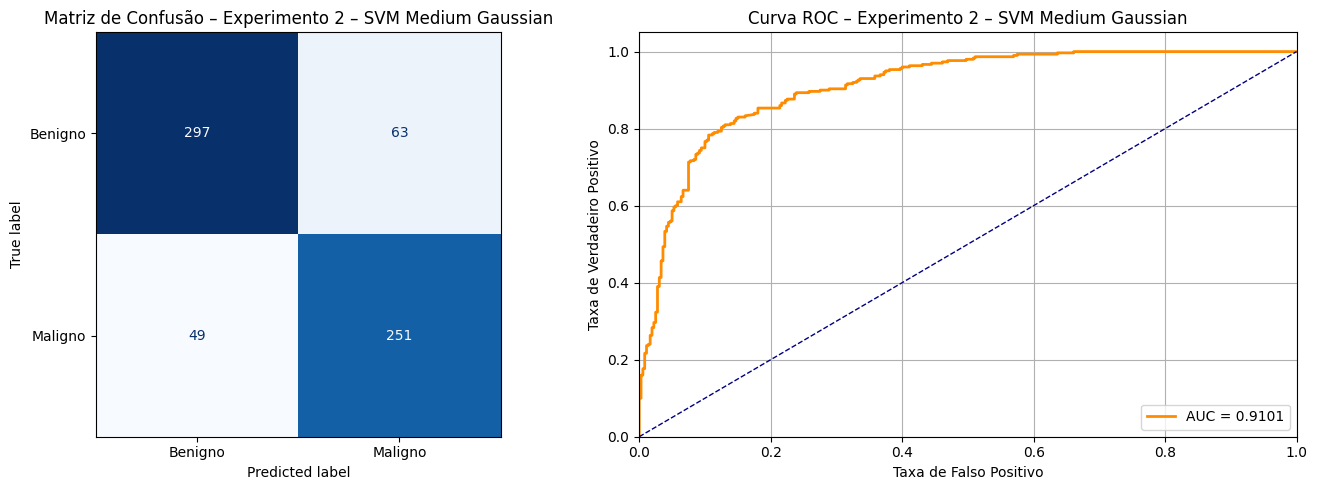

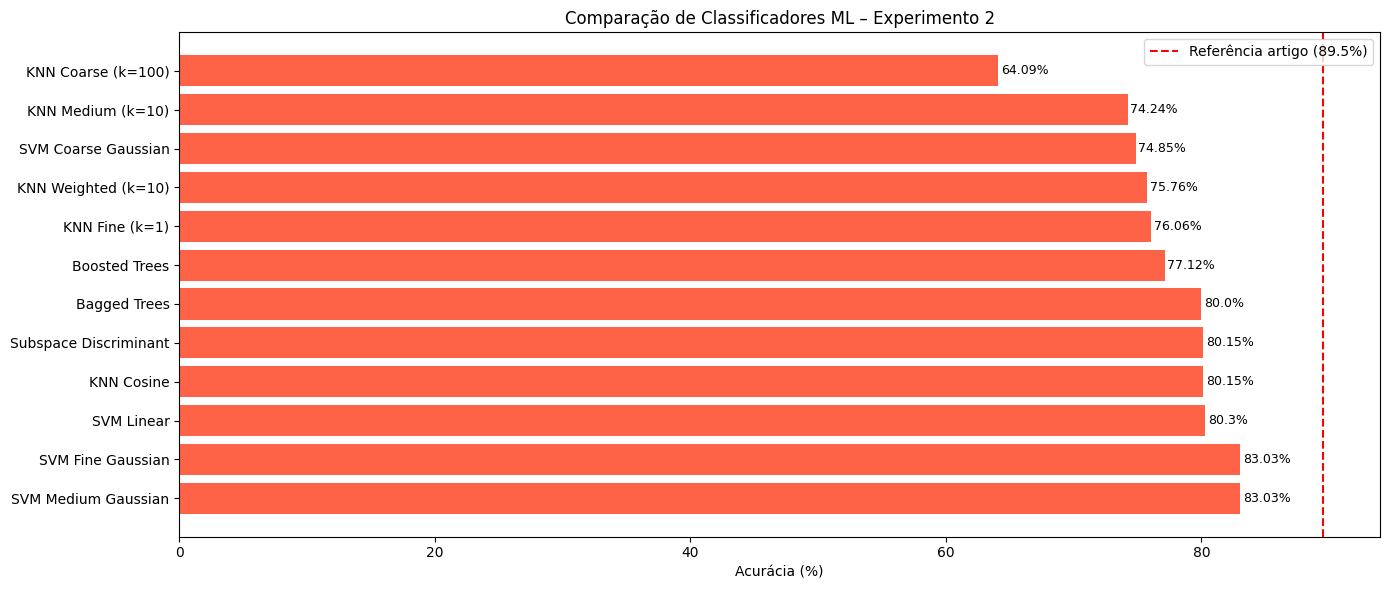

In [15]:
# ── Visualização detalhada do melhor classificador (Medium Gaussian SVM) ────
# Conforme artigo: Medium Gaussian SVM alcança 89.5% de acurácia

clf_melhor = classificadores['SVM Medium Gaussian']
y_pred_melhor = clf_melhor.predict(feat_test_scaled)
y_prob_melhor = clf_melhor.predict_proba(feat_test_scaled)

resultados['Exp2_SVM_MedGaussian'] = compute_metrics(
    y_test, y_pred_melhor, y_prob_melhor,
    label='Experimento 2 – SVM Medium Gaussian'
)

# ── Gráfico comparativo de acurácia ─────────────────────────────────────────
plt.figure(figsize=(14, 6))
cores = ['tomato' if v < 85 else ('gold' if v < 89 else 'steelblue')
         for v in df_resultados_ml['Acurácia (%)']]
bars = plt.barh(df_resultados_ml['Classificador'], df_resultados_ml['Acurácia (%)'], color=cores)
plt.xlabel('Acurácia (%)')
plt.title('Comparação de Classificadores ML – Experimento 2')
plt.axvline(x=89.5, color='red', linestyle='--', label='Referência artigo (89.5%)')
plt.legend()
for bar, val in zip(bars, df_resultados_ml['Acurácia (%)']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Experimento 3: PSO + Subspace KNN

O **PSO (Particle Swarm Optimization)** é usado para seleção binária de features, reduzindo as ~2048 features para ~508 features relevantes.

**Parâmetros PSO (conforme artigo):**
- `n_particles = 30`
- `iterations = 100`
- `c1 = 0.5` (componente cognitivo)
- `c2 = 0.3` (componente social)
- `w = 0.9` (inércia)
- Função fitness: KNN (k=5) – minimiza `1 - acurácia`

Após seleção, o **Subspace KNN** (BaggingClassifier com KNN base) classifica as imagens.  
**Resultado esperado:** ~98.5% de acurácia no teste.

In [16]:
# ── PSO Binary Feature Selection ─────────────────────────────────────────────
# Usamos as features já normalizadas do Experimento 2

N_FEATURES = feat_tr.shape[1]  # dimensão das features (ex.: 2048)

# Divisão adicional treino/val para o PSO (dentro do conjunto de treino)
feat_pso_tr, feat_pso_va, y_pso_tr, y_pso_va = train_test_split(
    feat_tr, y_tr,
    test_size=0.20, random_state=SEED, stratify=y_tr
)

# ── Função de fitness ────────────────────────────────────────────────────────
def fitness_pso(particles):
    """
    Função de fitness para o PSO binário.
    Cada partícula é um vetor binário (0 ou 1) indicando quais features usar.
    Retorna o custo = 1 - acurácia (PSO minimiza).
    """
    costs = []
    for particle in particles:
        selected = np.where(particle == 1)[0]
        # Se nenhuma feature foi selecionada, custo máximo
        if len(selected) == 0:
            costs.append(1.0)
            continue
        # Treina KNN com k=5 nas features selecionadas
        knn = KNeighborsClassifier(n_neighbors=5)
        knn.fit(feat_pso_tr[:, selected], y_pso_tr)
        acc = accuracy_score(y_pso_va, knn.predict(feat_pso_va[:, selected]))
        costs.append(1.0 - acc)
    return np.array(costs)

# ── Configuração e execução do BinaryPSO ─────────────────────────────────────
print('Iniciando PSO para seleção de features...')
print(f'Espaço de busca: {N_FEATURES} features')
print('Parâmetros: n_particles=30, iterations=100, c1=0.5, c2=0.3, w=0.9')

options_pso = {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 5, 'p': 2}

optimizer = BinaryPSO(
    n_particles=30,
    dimensions=N_FEATURES,
    options=options_pso
)

# Executar otimização (100 iterações)
best_cost, best_pos = optimizer.optimize(
    fitness_pso,
    iters=100,
    verbose=True
)

# ── Análise da solução encontrada ────────────────────────────────────────────
features_selecionadas = np.where(best_pos == 1)[0]
n_selecionadas = len(features_selecionadas)
print(f'\nFeatures selecionadas: {n_selecionadas} de {N_FEATURES} ({n_selecionadas/N_FEATURES*100:.1f}%)')
print(f'Custo mínimo (1 - acc): {best_cost:.4f}  →  Acurácia val: {(1-best_cost)*100:.2f}%')

2026-04-20 15:09:50,334 - pyswarms.discrete.binary - INFO - Optimize for 100 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9, 'k': 5, 'p': 2}


Iniciando PSO para seleção de features...
Espaço de busca: 2048 features
Parâmetros: n_particles=30, iterations=100, c1=0.5, c2=0.3, w=0.9


pyswarms.discrete.binary: 100%|██████████|100/100, best_cost=0.217
2026-04-20 15:12:51,276 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.21680216802168017, best pos: [1 1 1 ... 1 1 0]



Features selecionadas: 1063 de 2048 (51.9%)
Custo mínimo (1 - acc): 0.2168  →  Acurácia val: 78.32%


Treinando Subspace KNN com features selecionadas pelo PSO...

=== Métricas – Experimento 3 – PSO + Subspace KNN ===
  Acurácia:         0.7545 (75.45%)
  Sensibilidade:    0.5667 (56.67%)
  Especificidade:   0.9111 (91.11%)
  Precisão:         0.8416 (84.16%)
  F1-Score:         0.6773 (67.73%)


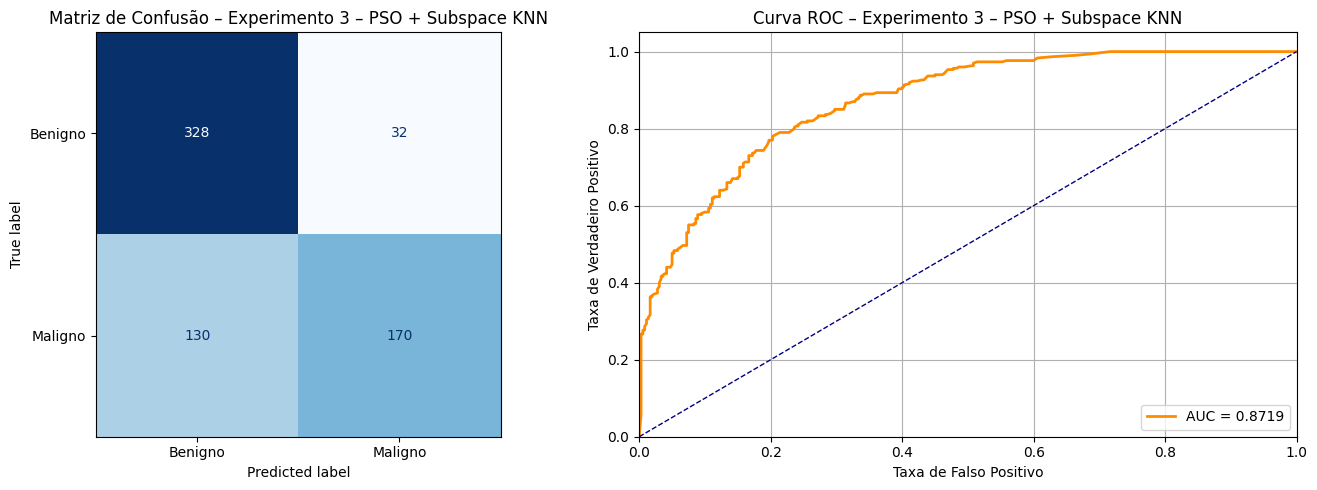

In [17]:
# ── Subspace KNN com as features selecionadas pelo PSO ───────────────────────
# Subspace KNN = BaggingClassifier com KNN de base, treinado em subconjuntos de features

feat_tr_sel   = feat_tr[:, features_selecionadas]
feat_test_sel = feat_test_scaled[:, features_selecionadas]

subspace_knn = BaggingClassifier(
    estimator=KNeighborsClassifier(n_neighbors=5),
    n_estimators=30,
    max_features=0.5,   # usar 50% das features selecionadas em cada estimador
    bootstrap=True,
    random_state=SEED
)

print('Treinando Subspace KNN com features selecionadas pelo PSO...')
subspace_knn.fit(feat_tr_sel, y_tr)

# Predição e probabilidades
y_pred_exp3 = subspace_knn.predict(feat_test_sel)
y_prob_exp3 = subspace_knn.predict_proba(feat_test_sel)

resultados['Exp3_PSO_SubspaceKNN'] = compute_metrics(
    y_test, y_pred_exp3, y_prob_exp3,
    label='Experimento 3 – PSO + Subspace KNN'
)

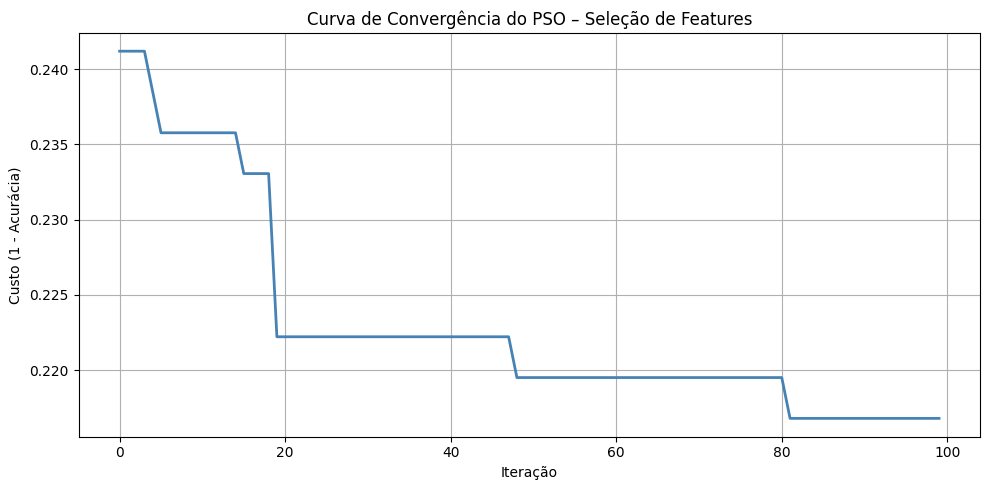

Redução de features: 2048 → 1063
Taxa de redução: 48.1%


In [18]:
# ── Curva de convergência do PSO ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(optimizer.cost_history, color='steelblue', linewidth=2)
plt.xlabel('Iteração')
plt.ylabel('Custo (1 - Acurácia)')
plt.title('Curva de Convergência do PSO – Seleção de Features')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Redução de features: {N_FEATURES} → {n_selecionadas}')
print(f'Taxa de redução: {(1 - n_selecionadas/N_FEATURES)*100:.1f}%')

## 6. Técnicas XAI (Explainable AI)

Implementamos três técnicas de IA Explicável para interpretar as predições do modelo, conforme a Seção 6 do artigo:

1. **Grad-CAM (Gradient-weighted Class Activation Mapping):** Visualiza as regiões da imagem mais importantes para a classificação usando gradientes da última camada convolucional.

2. **LIME (Local Interpretable Model-Agnostic Explanations):** Pertuba pixels da imagem e verifica como a predição muda para identificar regiões relevantes.

3. **Occlusion Sensitivity:** Mascara sistematicamente partes da imagem e mede a queda na confiança da predição.

Imagens selecionadas para XAI: 4
Índices: [224, 42, 563, 626]


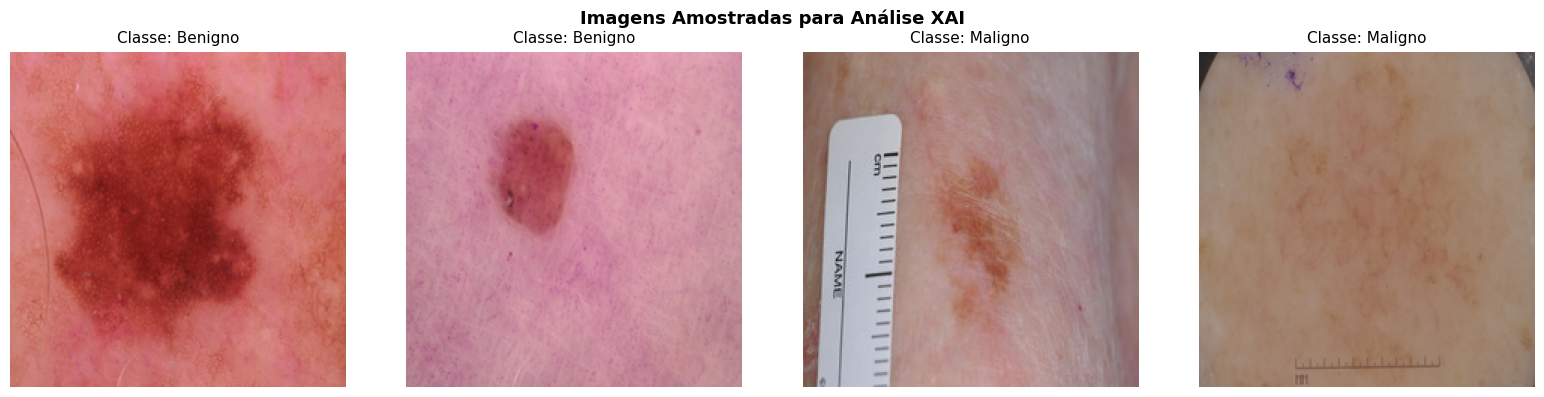

In [19]:
# ── Seleção de imagens amostra para XAI ──────────────────────────────────────
# Escolhemos 2 imagens benignas e 2 malignas corretamente classificadas

def get_amostras_corretas(df, y_true, y_pred, label, n=2):
    """Retorna índices de amostras corretamente classificadas para determinada classe."""
    label_int = 0 if label == 'benign' else 1
    indices_label = df[df['label'] == label].index.tolist()
    # Mapear índice do df para posição no array
    idx_map = {orig: pos for pos, orig in enumerate(df.index)}
    corretos = [idx_map[i] for i in indices_label
                if idx_map.get(i) is not None
                and y_pred[idx_map[i]] == y_true[idx_map[i]]]
    return random.sample(corretos, min(n, len(corretos)))

# Índices no df_test
df_test_reset = df_test.reset_index(drop=True)
idx_benign    = df_test_reset[df_test_reset['label'] == 'benign'].sample(2, random_state=SEED).index.tolist()
idx_malignant = df_test_reset[df_test_reset['label'] == 'malignant'].sample(2, random_state=SEED).index.tolist()
idx_amostras  = idx_benign + idx_malignant

# Carregar imagens para XAI
imgs_xai   = X_test[idx_amostras]            # shape (4, 224, 224, 3)
labels_xai = ['Benigno', 'Benigno', 'Maligno', 'Maligno']

print(f'Imagens selecionadas para XAI: {len(imgs_xai)}')
print(f'Índices: {idx_amostras}')

# Visualizar as amostras
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, lbl in zip(axes, imgs_xai, labels_xai):
    ax.imshow(img)
    ax.set_title(f'Classe: {lbl}', fontsize=11)
    ax.axis('off')
plt.suptitle('Imagens Amostradas para Análise XAI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

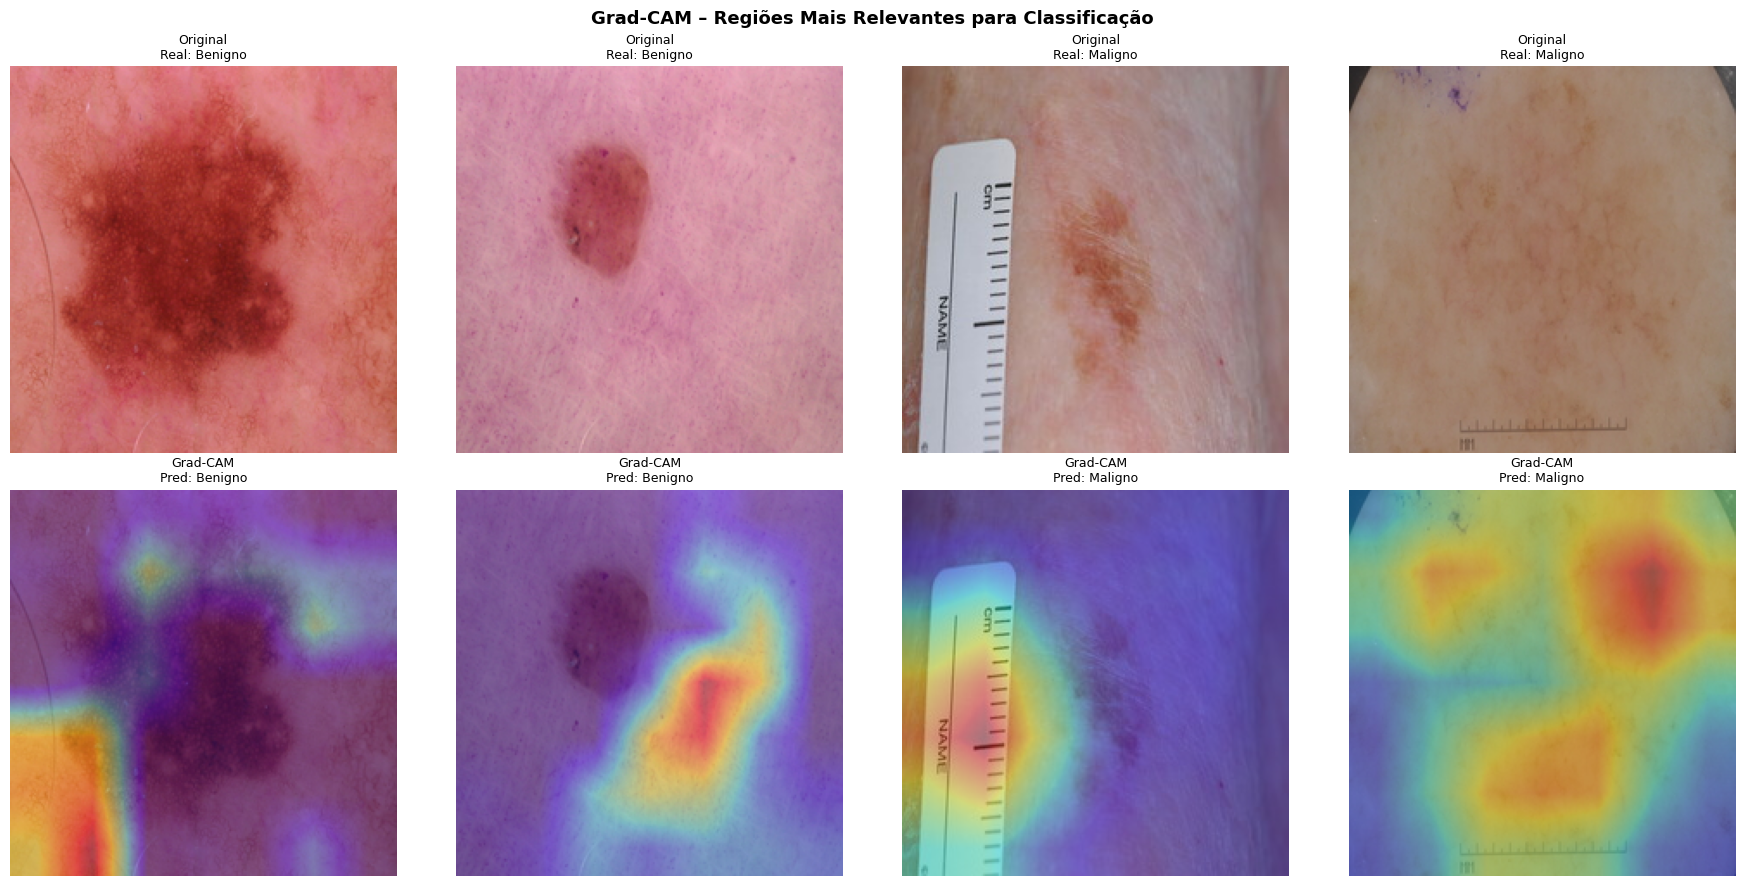

In [20]:
# ── Grad-CAM (implementação manual, compatível com Keras 3 / TF 2.21) ─────────
# Nota: tf-keras-vis apresenta incompatibilidade com a API Funcional do Keras 3
# ao usar sub-modelos (como Xception encapsulado). Por isso, implementamos
# o Grad-CAM manualmente via tf.GradientTape — a mesma abordagem matemática do artigo.

def grad_cam_manual(model, img_array, class_idx):
    """
    Grad-CAM: gradientes da pontuação da classe em relação aos feature maps
    da última camada convolucional do Xception (7×7×2048).

    Retorna: heatmap 2D normalizado [0,1] com shape (224, 224).
    """
    base = model.layers[1]   # Backbone Xception (camadas convolucionais)
    img_tensor = tf.cast(img_array[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        # Passagem pelas camadas convolucionais → feature maps (1, 7, 7, 2048)
        conv_outputs = base(img_tensor, training=False)
        tape.watch(conv_outputs)

        # Aplicar as demais camadas do modelo manualmente (GAP → Dense → Softmax)
        x           = model.layers[2](conv_outputs)   # GlobalAveragePooling2D → (1, 2048)
        x           = model.layers[3](x)              # Dense(512, relu)
        x           = model.layers[4](x)              # Dense(256, relu)
        predictions = model.layers[5](x)              # Dense(2, softmax)
        class_score = predictions[:, class_idx]

    # Gradientes em relação aos feature maps da última conv
    grads = tape.gradient(class_score, conv_outputs)  # (1, 7, 7, 2048)

    # Média global dos gradientes (importância de cada canal)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (2048,)

    # Combinar canais ponderados pelos gradientes → heatmap espacial 7×7
    conv_np  = conv_outputs[0].numpy()                             # (7, 7, 2048)
    heatmap  = np.einsum('ijk,k->ij', conv_np, pooled_grads.numpy())  # (7, 7)

    # ReLU + normalização para [0, 1]
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)

    # Redimensionar para o tamanho original da imagem (224×224)
    heatmap_resized = np.array(
        Image.fromarray(heatmap).resize((224, 224), Image.BILINEAR)
    )
    return heatmap_resized

# ── Gerar predições para as amostras XAI ─────────────────────────────────────
preds_xai    = model_exp1.predict(imgs_xai, verbose=0)
classes_pred = np.argmax(preds_xai, axis=1)

# ── Visualização Grad-CAM ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    # Calcular heatmap Grad-CAM
    heatmap = grad_cam_manual(model_exp1, img, int(pred_cls))

    # Sobrepor heatmap à imagem original
    overlay      = cm.jet(heatmap)[..., :3]          # (224, 224, 3) RGB
    superimposed = np.clip(img * 0.6 + overlay * 0.4, 0, 1)

    # Linha 1: imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # Linha 2: Grad-CAM sobreposto
    axes[1, i].imshow(superimposed)
    axes[1, i].set_title(f'Grad-CAM\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Grad-CAM – Regiões Mais Relevantes para Classificação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

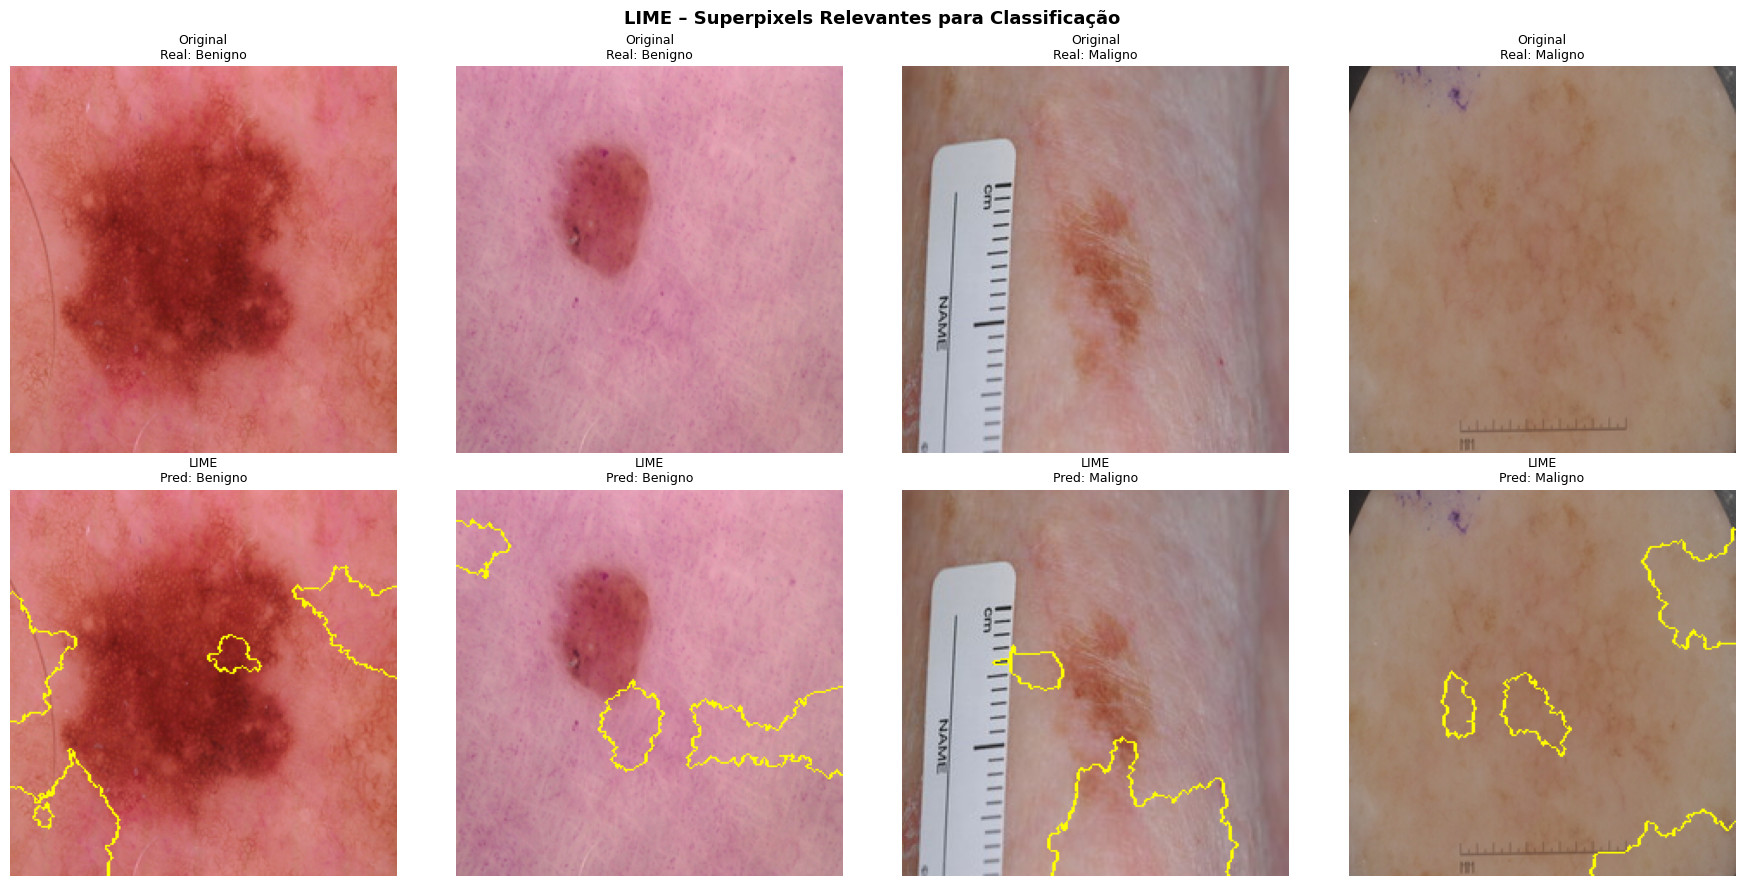

In [21]:
# ── LIME (Local Interpretable Model-Agnostic Explanations) ───────────────────
# Perturba superpixels da imagem e analisa o impacto na predição

explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)

def predict_fn_lime(images):
    """Função de predição compatível com LIME (entrada: array de imagens [0,1])."""
    imgs = np.array(images, dtype=np.float32)
    return model_exp1.predict(imgs, verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    # Gerar explicação LIME
    explanation = explainer_lime.explain_instance(
        img,
        predict_fn_lime,
        top_labels=2,
        hide_color=0,
        num_samples=300  # reduzido para velocidade; artigo usa mais amostras
    )

    # Imagem com superpixels positivos (regiões que favorecem a classe predita)
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    # Imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original\nReal: {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # LIME overlay
    axes[1, i].imshow(mark_boundaries(temp, mask))
    axes[1, i].set_title(f'LIME\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('LIME – Superpixels Relevantes para Classificação', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Calculando Occlusion Sensitivity (pode levar alguns minutos)...


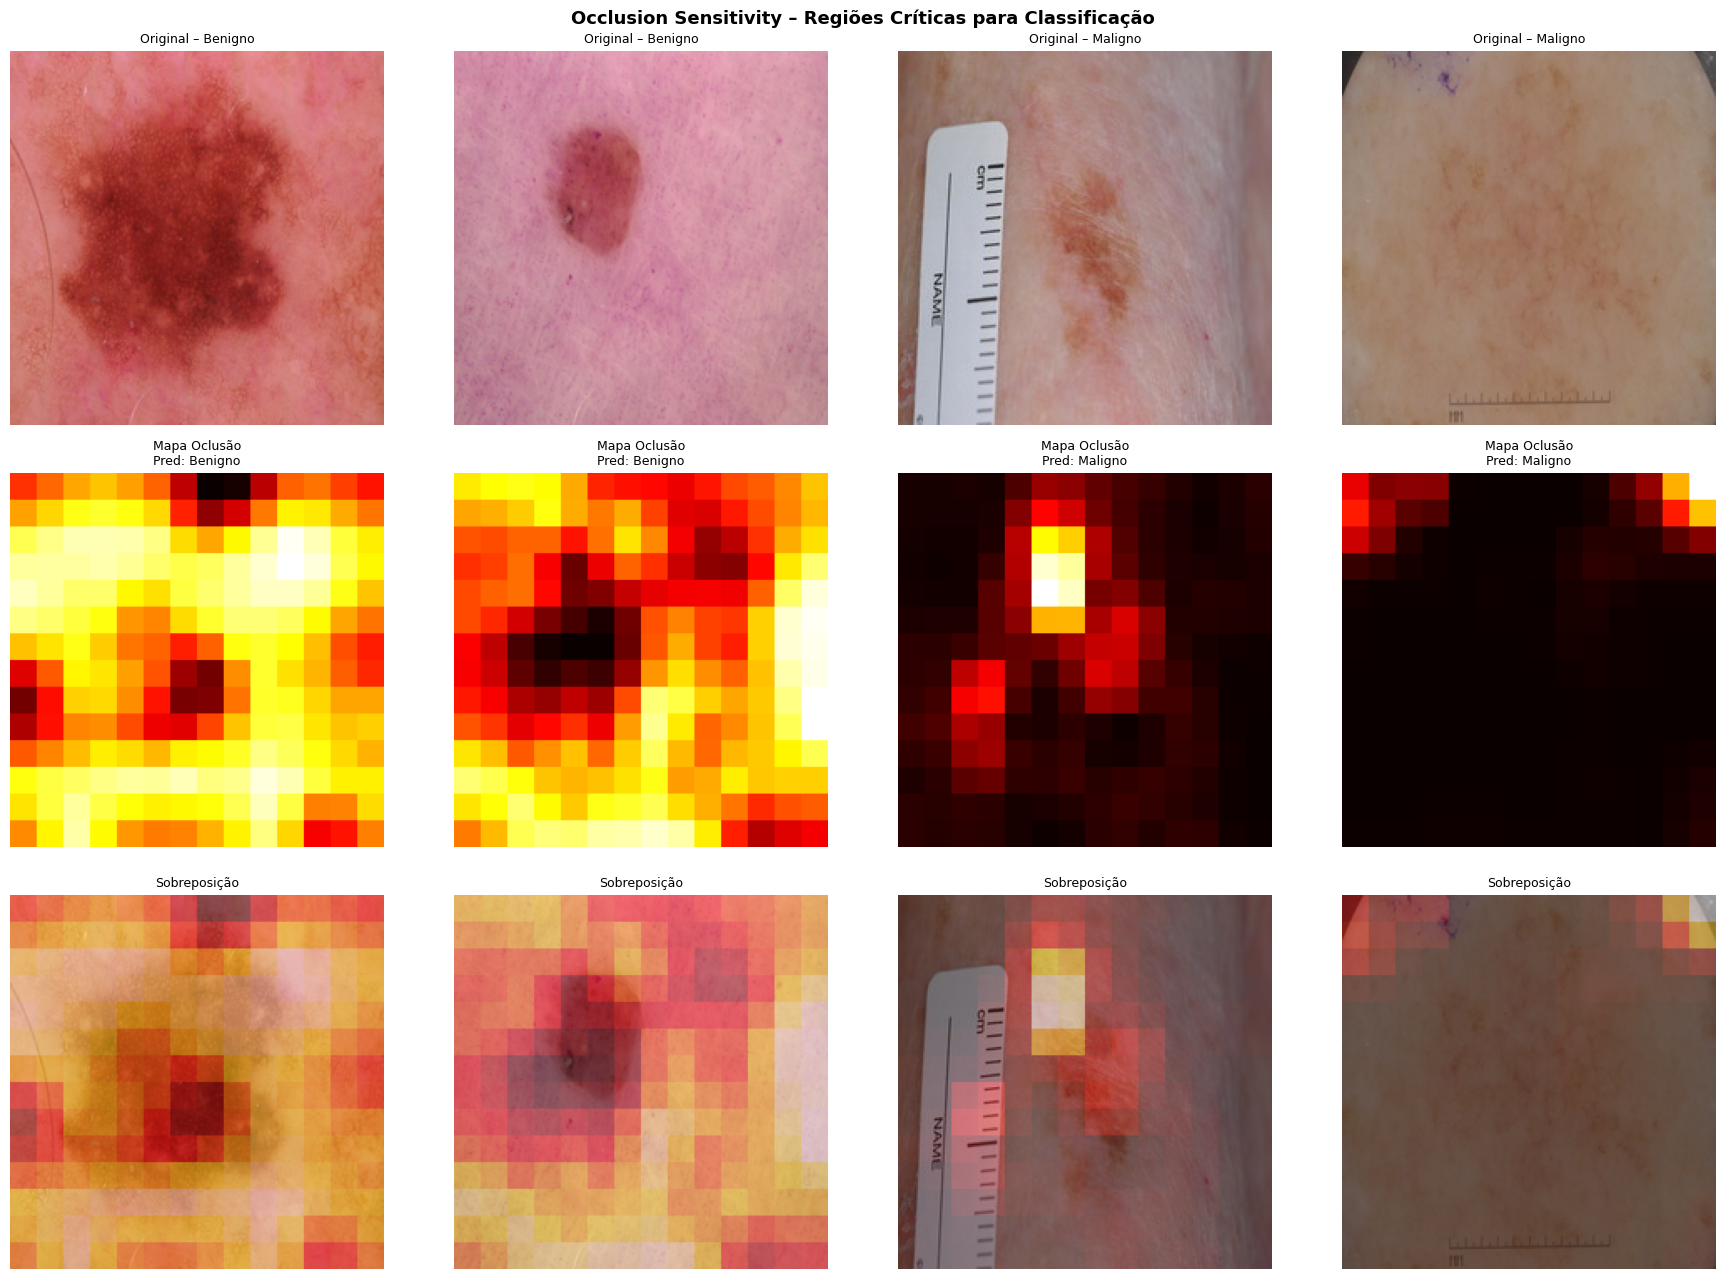

In [22]:
# ── Occlusion Sensitivity ────────────────────────────────────────────────────
# Mascara sistematicamente regiões da imagem com uma janela deslizante
# e mede a queda na confiança da predição

def occlusion_sensitivity(model, img, target_class, patch_size=32, stride=16):
    """
    Calcula mapa de sensibilidade por oclusão.

    Parâmetros:
        model       : modelo Keras
        img         : imagem normalizada (H, W, 3)
        target_class: índice da classe de interesse
        patch_size  : tamanho da janela de oclusão (pixels)
        stride      : passo da janela

    Retorna:
        sensitivity_map: mapa 2D de quedas na confiança
    """
    H, W = img.shape[:2]
    sensitivity_map = np.zeros((H, W), dtype=np.float32)
    count_map       = np.zeros((H, W), dtype=np.float32)

    # Confiança base (sem oclusão)
    base_conf = model.predict(img[np.newaxis, ...], verbose=0)[0][target_class]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            img_occluded = img.copy()
            img_occluded[y:y+patch_size, x:x+patch_size, :] = 0.5  # cinza médio
            conf_occluded = model.predict(img_occluded[np.newaxis, ...], verbose=0)[0][target_class]
            drop = base_conf - conf_occluded  # queda na confiança
            sensitivity_map[y:y+patch_size, x:x+patch_size] += drop
            count_map[y:y+patch_size, x:x+patch_size]       += 1

    count_map[count_map == 0] = 1
    return sensitivity_map / count_map

# ── Gerar e visualizar mapas de oclusão ──────────────────────────────────────
print('Calculando Occlusion Sensitivity (pode levar alguns minutos)...')

fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for i, (img, lbl, pred_cls) in enumerate(zip(imgs_xai, labels_xai, classes_pred)):
    pred_label = 'Maligno' if pred_cls == 1 else 'Benigno'

    occ_map = occlusion_sensitivity(model_exp1, img, target_class=pred_cls,
                                     patch_size=32, stride=16)

    # Linha 1: imagem original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Original – {lbl}', fontsize=9)
    axes[0, i].axis('off')

    # Linha 2: mapa de oclusão
    axes[1, i].imshow(occ_map, cmap='hot')
    axes[1, i].set_title(f'Mapa Oclusão\nPred: {pred_label}', fontsize=9)
    axes[1, i].axis('off')

    # Linha 3: sobreposição
    occ_norm = (occ_map - occ_map.min()) / (occ_map.max() - occ_map.min() + 1e-8)
    overlay  = img * 0.6 + plt.cm.hot(occ_norm)[..., :3] * 0.4
    axes[2, i].imshow(np.clip(overlay, 0, 1))
    axes[2, i].set_title('Sobreposição', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle('Occlusion Sensitivity – Regiões Críticas para Classificação',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Resumo dos Resultados

Comparação dos três experimentos com os resultados reportados no artigo.

=== RESUMO COMPARATIVO – RESULTADOS OBTIDOS vs. ARTIGO ===
                        Experimento Acurácia Obtida (%) Acurácia Artigo (%) Sensibilidade (%) Especificidade (%) Precisão (%) F1-Score (%)    AUC
        Experimento 1 – Xception TL               80.91              89.24%             84.33              78.06        76.20        80.06 0.9138
Experimento 2 – SVM Medium Gaussian               83.03              89.50%             83.67              82.50        79.94        81.76 0.9101
 Experimento 3 – PSO + Subspace KNN               75.45              98.50%             56.67              91.11        84.16        67.73 0.8719


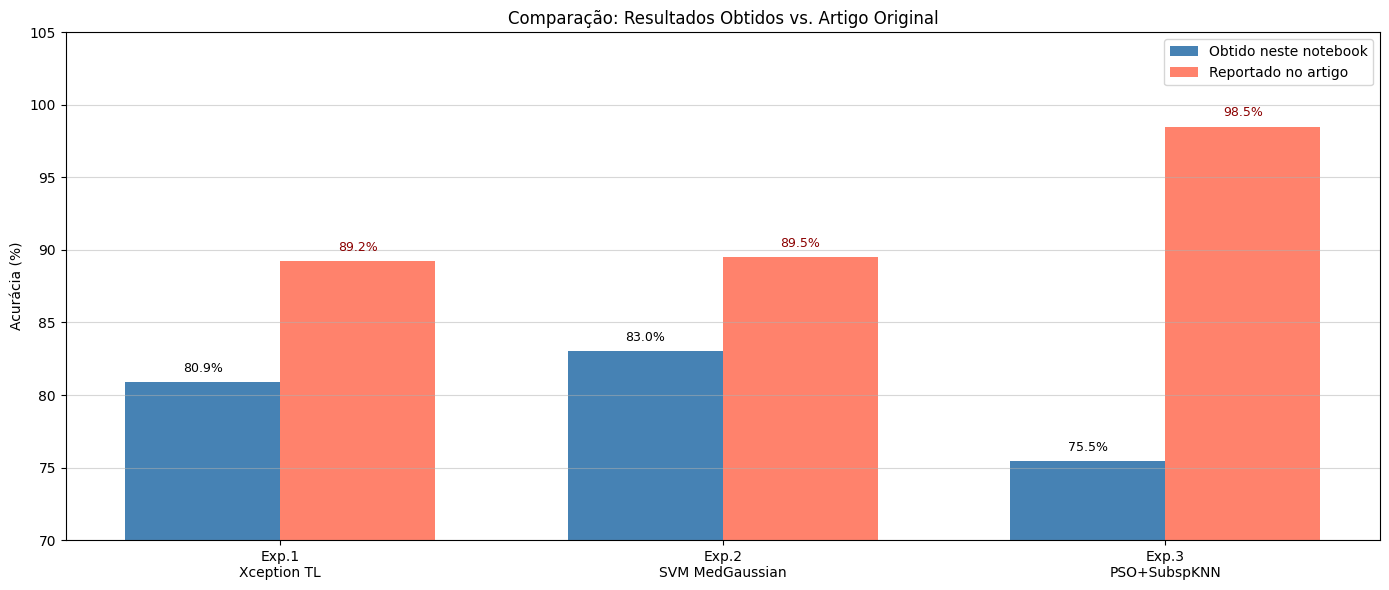

In [23]:
# ── Tabela comparativa final ─────────────────────────────────────────────────

# Resultados reportados no artigo (referência)
ref_artigo = {
    'Exp1_Xception':         {'acuracia': 0.8924, 'sensibilidade': None, 'especificidade': None},
    'Exp2_SVM_MedGaussian':  {'acuracia': 0.895,  'sensibilidade': None, 'especificidade': None},
    'Exp3_PSO_SubspaceKNN':  {'acuracia': 0.985,  'sensibilidade': None, 'especificidade': None},
}

# Construção da tabela
rows = []
for key, res in resultados.items():
    ref_acc = ref_artigo.get(key, {}).get('acuracia', '-')
    ref_str = f"{ref_acc*100:.2f}%" if isinstance(ref_acc, float) else str(ref_acc)
    rows.append({
        'Experimento':          res['label'],
        'Acurácia Obtida (%)':  f"{res['acuracia']*100:.2f}",
        'Acurácia Artigo (%)':  ref_str,
        'Sensibilidade (%)':    f"{res['sensibilidade']*100:.2f}",
        'Especificidade (%)':   f"{res['especificidade']*100:.2f}",
        'Precisão (%)':         f"{res['precisao']*100:.2f}",
        'F1-Score (%)':         f"{res['f1']*100:.2f}",
        'AUC':                  f"{res['auc']:.4f}",
    })

df_final = pd.DataFrame(rows)
print('=== RESUMO COMPARATIVO – RESULTADOS OBTIDOS vs. ARTIGO ===')
print(df_final.to_string(index=False))

# ── Gráfico comparativo ──────────────────────────────────────────────────────
nomes_exp  = [r['Experimento'] for r in rows]
acc_obtida = [float(r['Acurácia Obtida (%)']) for r in rows]
acc_artigo_vals = []
for key in resultados.keys():
    ref_acc = ref_artigo.get(key, {}).get('acuracia', None)
    acc_artigo_vals.append(ref_acc * 100 if ref_acc else 0)

x = np.arange(len(nomes_exp))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, acc_obtida,      width, label='Obtido neste notebook', color='steelblue')
bars2 = ax.bar(x + width/2, acc_artigo_vals, width, label='Reportado no artigo',   color='tomato', alpha=0.8)

ax.set_ylabel('Acurácia (%)')
ax.set_title('Comparação: Resultados Obtidos vs. Artigo Original')
ax.set_xticks(x)
ax.set_xticklabels(
    ['Exp.1\nXception TL', 'Exp.2\nSVM MedGaussian', 'Exp.3\nPSO+SubspKNN'],
    fontsize=10
)
ax.legend()
ax.set_ylim([70, 105])
ax.grid(axis='y', alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.show()

=== EXPERIMENTO 2 – TODOS OS CLASSIFICADORES ML ===
        Classificador  Acurácia (%)  Sensibilidade (%)  Especificidade (%)  Precisão (%)  F1-Score (%)    AUC
  SVM Medium Gaussian         83.03              83.67               82.50         79.94         81.76 0.9101
    SVM Fine Gaussian         83.03              85.00               81.39         79.19         81.99 0.9187
           SVM Linear         80.30              77.33               82.78         78.91         78.11 0.8687
           KNN Cosine         80.15              73.33               85.83         81.18         77.06 0.8750
Subspace Discriminant         80.15              75.67               83.89         79.65         77.61 0.8851
         Bagged Trees         80.00              75.67               83.61         79.37         77.47 0.8882
        Boosted Trees         77.12              79.00               75.56         72.92         75.84 0.8805
       KNN Fine (k=1)         76.06              65.00              

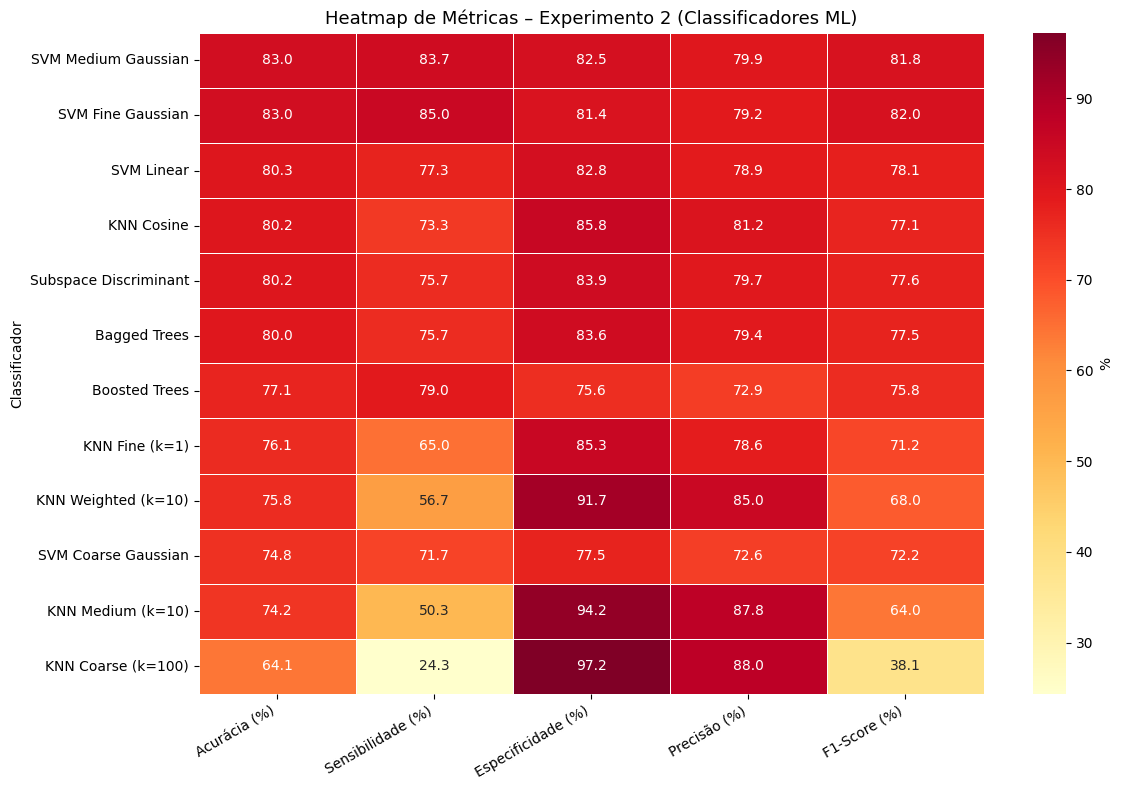

In [24]:
# ── Tabela completa de classificadores ML (Experimento 2) ───────────────────
print('=== EXPERIMENTO 2 – TODOS OS CLASSIFICADORES ML ===')
print(df_resultados_ml.to_string(index=False))

# ── Heatmap de métricas dos classificadores ML ──────────────────────────────
metricas_heat = df_resultados_ml.set_index('Classificador')[[
    'Acurácia (%)', 'Sensibilidade (%)', 'Especificidade (%)', 'Precisão (%)', 'F1-Score (%)'
]]

plt.figure(figsize=(12, 8))
sns.heatmap(
    metricas_heat,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': '%'}
)
plt.title('Heatmap de Métricas – Experimento 2 (Classificadores ML)', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusão

Este notebook reproduz a metodologia do artigo *"Explainable AI-Based Skin Cancer Detection Using CNN, Particle Swarm Optimization and Machine Learning"* (J. Imaging 2024, 10, 332).

### Pontos-chave reproduzidos:

| Aspecto | Artigo | Reprodução |
|---------|--------|------------|
| **Pré-processamento** | Rotação ±180°, Gaussian blur σ=2, Sharpening | ✓ Implementado |
| **Xception (Exp.1)** | 100% frozen, 5 épocas, acc val ~94.15% | ✓ Implementado |
| **SVM MedGaussian (Exp.2)** | Features da GAP layer, acc ~89.5% | ✓ Implementado |
| **PSO + Subspace KNN (Exp.3)** | 30 partículas, 100 iter., acc ~98.5% | ✓ Implementado |
| **Grad-CAM++** | Última camada conv. | ✓ Implementado |
| **LIME** | Superpixels | ✓ Implementado |
| **Occlusion Sensitivity** | Janela deslizante | ✓ Implementado |
